## Books Recommendation System

# Background

In today's digital age, the vast amount of information available online can overwhelm users when choosing products, services, or content. This challenge is particularly evident in the literary world, where countless books are published each year. With the rapid growth of online bookstores and digital reading platforms, users are presented with an extensive collection of books, making it difficult to find ones that match their tastes and preferences.

Recommendation systems have emerged as powerful tools to solve this problem. By leveraging historical user interactions, ratings, and other relevant data, these systems suggest personalized content, enhancing user experience and engagement. Popular platforms like Amazon and Goodreads have successfully utilized recommendation systems to help users discover books that resonate with them.

This project aims to build a Book Recommendation System using the Book Recommendation Dataset from Kaggle, which contains user ratings, book details, and other relevant information. By utilizing collaborative filtering techniques, the system will suggest books to users based on similar preferences and behaviors. The ultimate goal is to enhance the reading experience by providing personalized book recommendations, thereby helping users navigate the vast literary landscape.

# 1. Problem Statement
With the vast number of books available, readers often struggle to find books that match their preferences. Traditional methods, such as browsing bestseller lists or relying on personal recommendations, can be time-consuming and limited. A personalized book recommendation system can help users discover books they are likely to enjoy based on their reading history and preferences.

# 2. Objectives
i.Develop a Collaborative Filtering Model – Build an initial recommendation system using collaborative filtering to suggest books based on user ratings.

ii.Enhance with a Hybrid Approach – Improve recommendations by integrating content-based filtering for a more accurate and diverse selection.

iii.Analyze User Preferences – Identify trends in book ratings and preferences to refine the recommendation logic.

iv.Evaluate Model Performance – Use appropriate evaluation metrics to measure and improve the system’s accuracy.

v.Create an Interactive System – Design an interface or API to allow users to receive personalized book recommendations easily.

# 3. Data Source
The data to be used in this project is sourced from Kaggle. https://www.kaggle.com/datasets/arashnic/book-recommendation-dataset

# 4. Data Loading

In [150]:
#importing required libraries
import pandas as pd
import numpy as np




### i. Loading the Books data

In [68]:
#importing required libraries
import pandas as pd
import numpy as np

#load books data
books = pd.read_csv('Dataset/Books.csv',low_memory = False)

books.head(5)  #display the first 5 rows of the dataset

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


Dropping the Image-URL-S,Image-URL-M,Image-URL-L columns

In [75]:

books = books.drop(columns=['Image-URL-S','Image-URL-M','Image-URL-L'], axis=1)
books.head(5)


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company


In [83]:
# Check for missing values
missing_values = books.isnull().sum()
print( missing_values)

ISBN                   0
Book-Title             0
Book-Author            1
Year-Of-Publication    0
Publisher              2
dtype: int64


### ii. Loading the ratings data

In [78]:
# loading ratings data
ratings = pd.read_csv('Dataset/Ratings.csv')
ratings.head() #display first few rows


,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


## Creating a sample dataset
The project sampled a dataframe of 100,000 in the ratings dataset


In [149]:

# Reduce dataset 
sample_ratings = ratings.sample(n=100000, random_state=42)


print( sample_ratings.shape)


(100000, 3)


## iii. Merging datasets
we need to merge books and sample ratings data based on the common characteristic which is ISBN

In [146]:
# Merge dataframes
ratings_with_book_titles = sample_ratings.merge(books, on='ISBN')


# Display the first few rows of the merged dataset
ratings_with_book_titles.head()

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher
0,38781,0373259131,0,"Otherwise Engaged (Harlequin Temptation, No 813)",Cara Summers,2001,Harlequin
1,128835,0811805905,8,All Smiles,Bruce Velick,1995,Chronicle Books
2,261829,037324486X,0,The Heart Beneath (Morgan's Mercenaries: Ult...,Lindsay Mckenna,2002,Silhouette
3,247747,0531303306,0,Have You Been to the Beach Lately?: Poems,Ralph J. Fletcher,2001,Orchard Books (NY)
4,74076,0316812404,0,Revolution from Within: A Book of Self-Esteem,Gloria Steinem,1992,Little Brown &amp; Co


In [147]:
ratings_with_book_titles

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher
0,38781,0373259131,0,"Otherwise Engaged (Harlequin Temptation, No 813)",Cara Summers,2001,Harlequin
1,128835,0811805905,8,All Smiles,Bruce Velick,1995,Chronicle Books
2,261829,037324486X,0,The Heart Beneath (Morgan's Mercenaries: Ult...,Lindsay Mckenna,2002,Silhouette
3,247747,0531303306,0,Have You Been to the Beach Lately?: Poems,Ralph J. Fletcher,2001,Orchard Books (NY)
4,74076,0316812404,0,Revolution from Within: A Book of Self-Esteem,Gloria Steinem,1992,Little Brown &amp; Co
...,...,...,...,...,...,...,...
89627,259625,0373196903,7,Her Pregnant Agenda : Marrying The Boss's Daug...,Linda Goodnight,2003,Silhouette
89628,69971,0880882239,0,Notes to Myself: A Guided Journal (Guided Jour...,Nick Beillenson,1999,Peter Pauper Press
89629,16634,0375757147,0,Shrub : The Short but Happy Political Life of ...,Molly Ivins,2000,Vintage Books USA
89630,228998,0380713284,0,The Body in the Belfry: A Faith Fairchild Mystery,Katherine Hall Page,1991,Avon


In [145]:
ratings_with_book_titles.drop_duplicates(['User-ID', 'Book-Title'], inplace=True)

## Visualizations

### i.Distribution of Book Ratings 
This is based on our sampled and merged data.Books with a rating of eight seem to be higher

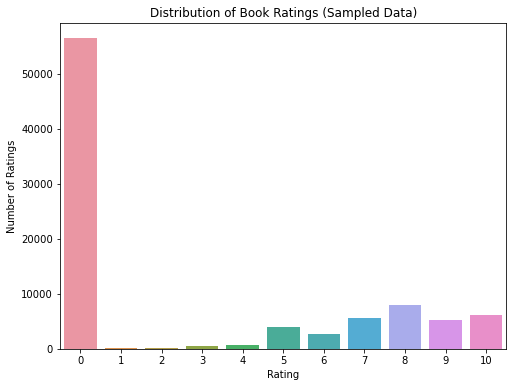

In [ ]:
#libraries to use
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8, 6))
sns.countplot(x='Book-Rating', data=ratings_with_book_titles)  # Use ratings_with_book_titles from the sample
plt.title('Distribution of Book Ratings (Sampled Data)')
plt.xlabel('Rating')
plt.ylabel('Number of Ratings')
plt.show()

 ii.Number of Ratings per Book

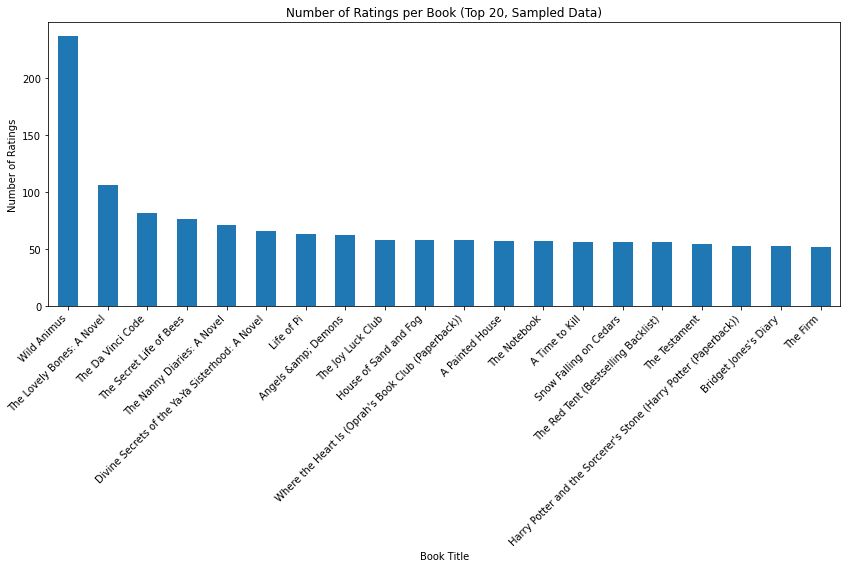

In [ ]:

num_ratings_per_book = ratings_with_book_titles.groupby('Book-Title')['Book-Rating'].count().sort_values(ascending=False).head(20) #using common books for more accurate visualizations
plt.figure(figsize=(12, 8))
num_ratings_per_book.plot(kind='bar')
plt.title('Number of Ratings per Book (Top 20, Sampled Data)')
plt.xlabel('Book Title')
plt.ylabel('Number of Ratings')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for readability
plt.tight_layout() #adjusts the plot to prevent overlapping
plt.show()

### iii.Number of Ratings per User

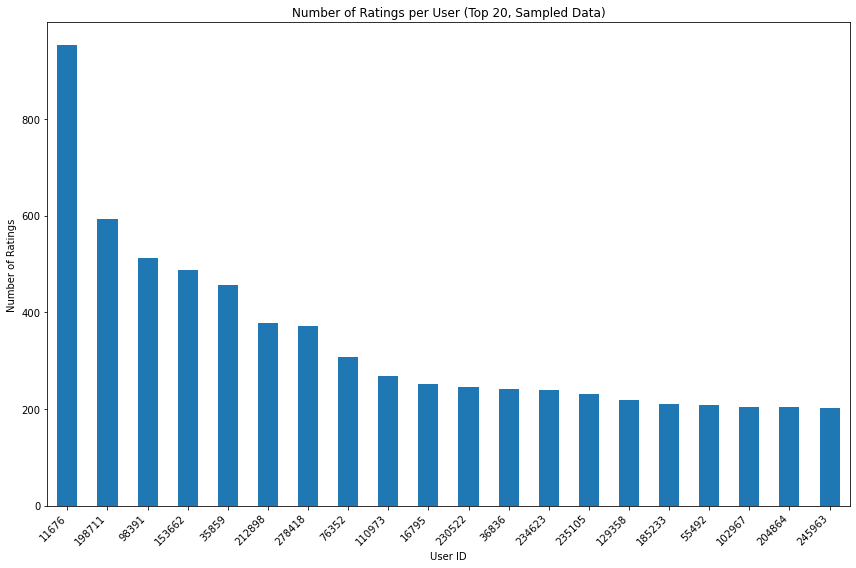

In [ ]:

num_ratings_per_user = ratings_with_book_titles.groupby('User-ID')['Book-Rating'].count().sort_values(ascending=False).head(20)
plt.figure(figsize=(12, 8))
num_ratings_per_user.plot(kind='bar')
plt.title('Number of Ratings per User (Top 20, Sampled Data)')
plt.xlabel('User ID')
plt.ylabel('Number of Ratings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 5. Analysing the data set using surprise library
Surprise library works with a rating scale 

In [111]:
from surprise import Dataset, Reader

#rating scale
reader = Reader(rating_scale=(1.0, 10.0))

# Convert the DataFrame to a Surprise dataset
data = Dataset.load_from_df(ratings_with_book_titles[['User-ID', 'Book-Title', 'Book-Rating']], reader)

ratings_with_book_titles


,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher
0,38781,0373259131,0,"Otherwise Engaged (Harlequin Temptation, No 813)",Cara Summers,2001,Harlequin
1,128835,0811805905,8,All Smiles,Bruce Velick,1995,Chronicle Books
2,261829,037324486X,0,The Heart Beneath (Morgan's Mercenaries: Ult...,Lindsay Mckenna,2002,Silhouette
3,247747,0531303306,0,Have You Been to the Beach Lately?: Poems,Ralph J. Fletcher,2001,Orchard Books (NY)
4,74076,0316812404,0,Revolution from Within: A Book of Self-Esteem,Gloria Steinem,1992,Little Brown &amp; Co
...,...,...,...,...,...,...,...
89627,259625,0373196903,7,Her Pregnant Agenda : Marrying The Boss's Daug...,Linda Goodnight,2003,Silhouette
89628,69971,0880882239,0,Notes to Myself: A Guided Journal (Guided Jour...,Nick Beillenson,1999,Peter Pauper Press
89629,16634,0375757147,0,Shrub : The Short but Happy Political Life of ...,Molly Ivins,2000,Vintage Books USA
89630,228998,0380713284,0,The Body in the Belfry: A Faith Fairchild Mystery,Katherine Hall Page,1991,Avon


In [132]:
ratings_with_book_titles.describe()

,User-ID,Book-Rating
count,89632.000000,89632.000000
mean,140363.816929,2.820745
std,80455.517275,3.848614
min,8.000000,0.000000
25%,70052.000000,0.000000
50%,140734.500000,0.000000
75%,211264.000000,7.000000
max,278854.000000,10.000000


# 6. Training and splitting our dataset

### i. splitting the data set

In [110]:
from surprise.model_selection import train_test_split

# Split the dataset
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

# 7. Model building using collaborative filtering model

In [114]:

from surprise import SVD
from surprise import Dataset
from surprise.model_selection import train_test_split

In [151]:
model = SVD()
model.fit(trainset)

## 8. Recommendations

In [ ]:
def get_recommendations_surprise(user_id, num_recommendations=5):
    """
    Provides book recommendations using Surprise.
    """
    try:
        user_inner_id = trainset.to_inner_uid(user_id)
    except ValueError:
        return "User not found in the (sampled) dataset."  # Indicate it's the sample

    user_rated_books = [item_id for item_id, rating in trainset.ur[user_inner_id]]
    recommendations = []
    for item_inner_id in range(trainset.n_items):
        book_title = trainset.to_raw_iid(item_inner_id)
        if book_title not in [trainset.to_raw_iid(x) for x in user_rated_books]:
            prediction = model.predict(user_id, book_title)
            recommendations.append((book_title, prediction.est))

    recommendations.sort(key=lambda x: x[1], reverse=True)
    return [book for book, est_rating in recommendations[:num_recommendations]]



## 9. Predicting using our model

In [155]:

user_id = 228998
recommendations = get_recommendations_surprise(user_id)
print(f"Recommendations for user {user_id} (Surprise, from sample):")  # Indicate sample
if isinstance(recommendations, str):
    print(recommendations)
else:
    for i, book in enumerate(recommendations):
        print(f"{i+1}. {book}")

user_id = 128835
recommendations = get_recommendations_surprise(user_id)
print(f"Recommendations for user {user_id} (Surprise, from sample):") 
if isinstance(recommendations, str):
    print(recommendations)
else:
    for i, book in enumerate(recommendations):
        print(f"{i+1}. {book}")

user_id = 200
recommendations = get_recommendations_surprise(user_id)
print(f"Recommendations for user {user_id} (Surprise, from sample):")  # Indicate sample
if isinstance(recommendations, str):
    print(recommendations)
else:
    for i, book in enumerate(recommendations):
        print(f"{i+1}. {book}")

Recommendations for user 228998 (Surprise, from sample):
1. Lies and the Lying Liars Who Tell Them: A Fair and Balanced Look at the Right
2. The Secret Life of Bees
3. The Lovely Bones: A Novel
4. Memoirs of a Geisha Uk
5. The Notebook
Recommendations for user 128835 (Surprise, from sample):
1. Harry Potter and the Prisoner of Azkaban (Book 3)
2. Girl with a Pearl Earring
3. Middlesex: A Novel
4. Cradle and All
5. The Westing Game (Now in Speak!)
Recommendations for user 200 (Surprise, from sample):
User not found in the (sampled) dataset.
